In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import pandas as pd
import snowflake.connector
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv('/Users/roelsomido/dbt_projects/.env')

try:
    conn = snowflake.connector.connect(
        user=os.getenv('SNOWFLAKE_USER'),
        password=os.getenv('SNOWFLAKE_PASSWORD'),
        account=os.getenv('SNOWFLAKE_ACCOUNT'),
        warehouse=os.getenv('SNOWFLAKE_WAREHOUSE'),
        database=os.getenv('SNOWFLAKE_DATABASE'),
        schema=os.getenv('SNOWFLAKE_SCHEMA')
    )

    with conn.cursor() as cur:
        cur.execute("SELECT 1;")
        result = cur.fetchone()

    print("✅ Connection Successful! Verified with test query result:", result[0])

except snowflake.connector.errors.ProgrammingError as e:
    print(f"❌ Connection Failed! Please check your credentials or account details.\nError: {e}")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Connection Successful! Verified with test query result: 1


In [3]:
cur = conn.cursor()

query = "SELECT * FROM RAW_DB.ECOM_SOURCE.MART_CUSTOMER_SALES"
cur.execute(query)

df = cur.fetch_pandas_all()
df.head()

,CUSTOMER_KEY,CUSTOMER_ID,FIRST_NAME,LAST_NAME,COUNTRY,GENDER,BIRTH_DATE,TOTAL_ORDERS,TOTAL_ORDER_LINES,TOTAL_UNITS_PURCHASED,LIFETIME_SALES,AVG_LINE_VALUE,FIRST_ORDER_DATE,LAST_ORDER_DATE,DAYS_SINCE_LAST_ORDER
0,25249,25249,Alexandra,Watson,Australia,Female,1963-02-05,2,5,5,1868,373.600000,2011-01-02,2013-08-23,4740.0
1,14558,14558,Marcel,Truempy,United States,Female,1981-11-08,2,4,4,1527,381.750000,2011-01-25,2013-06-11,4813.0
2,28071,28071,Trevor,Ross,United States,Male,1985-01-06,2,3,3,5971,1990.333333,2011-02-08,2013-12-10,4631.0
3,18495,18495,Jeremy,Phillips,Australia,Male,1969-08-30,2,2,2,6021,3010.500000,2011-06-07,2013-03-18,4898.0
4,28839,28839,Connor,Parker,United States,Male,1982-04-09,1,1,1,3578,3578.000000,2011-06-30,2011-06-30,5525.0


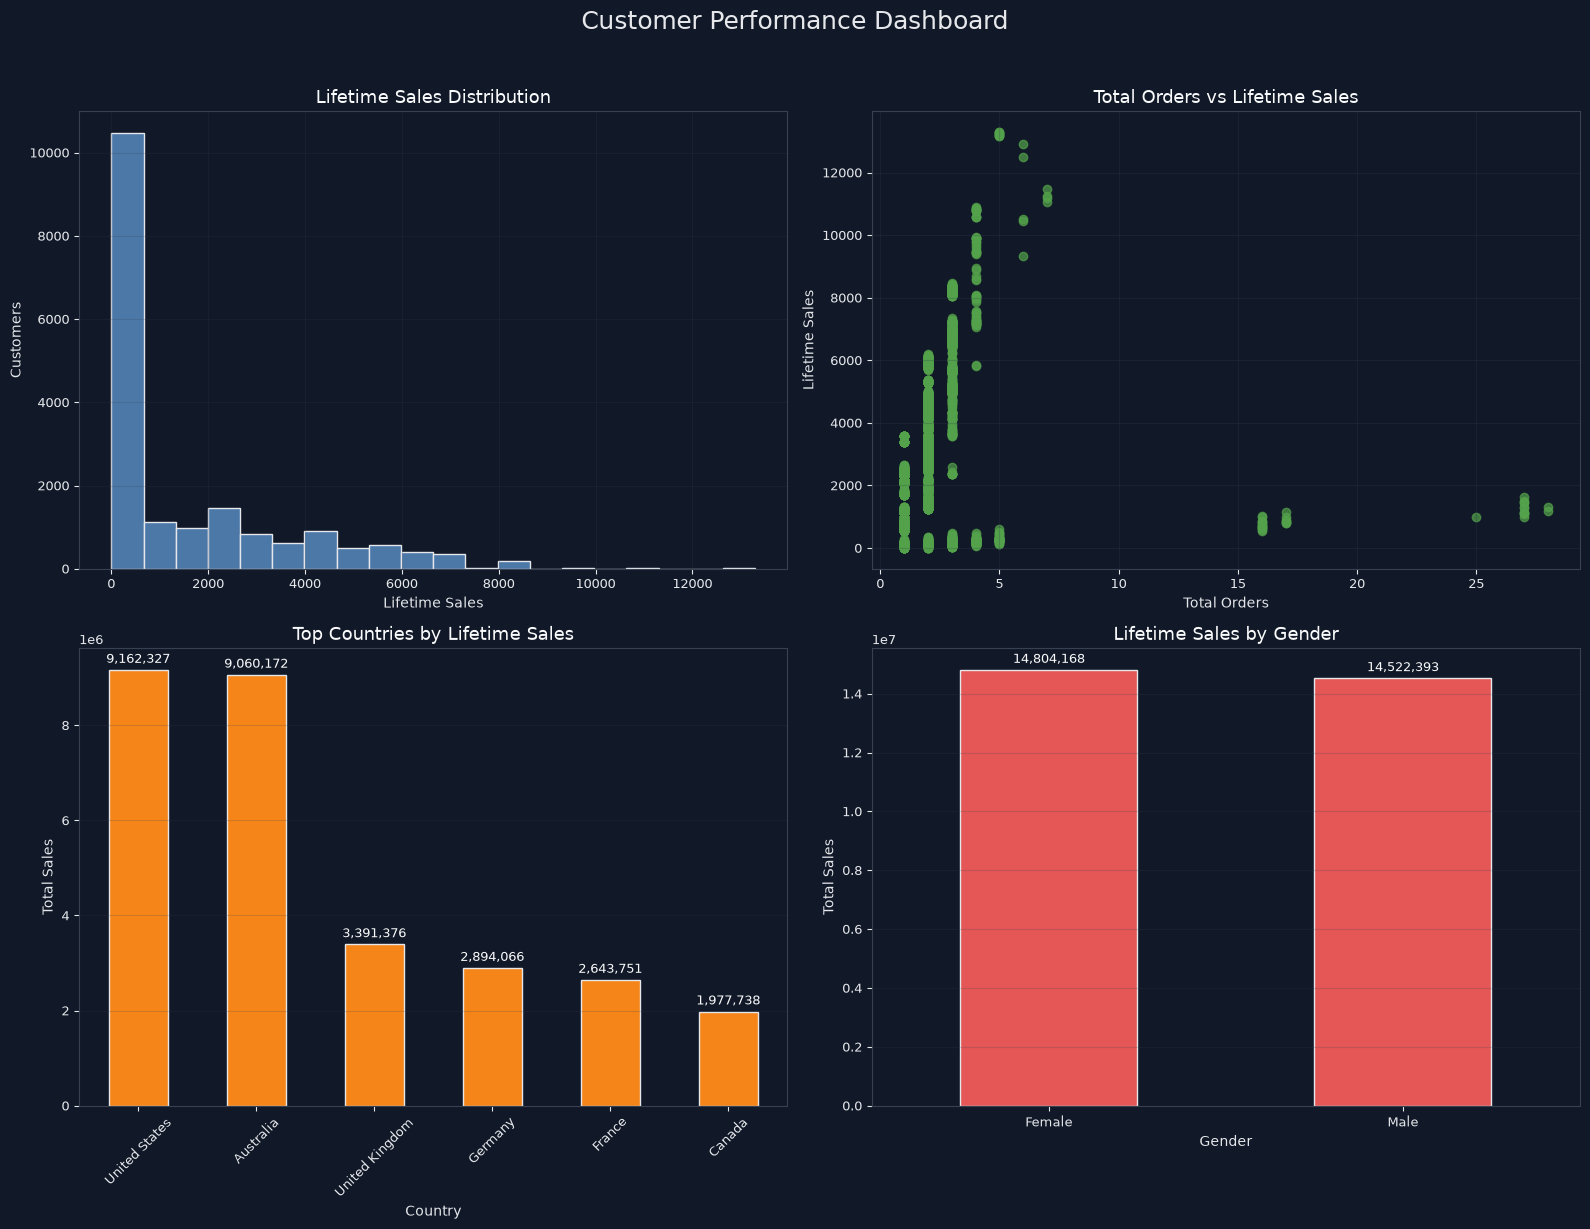

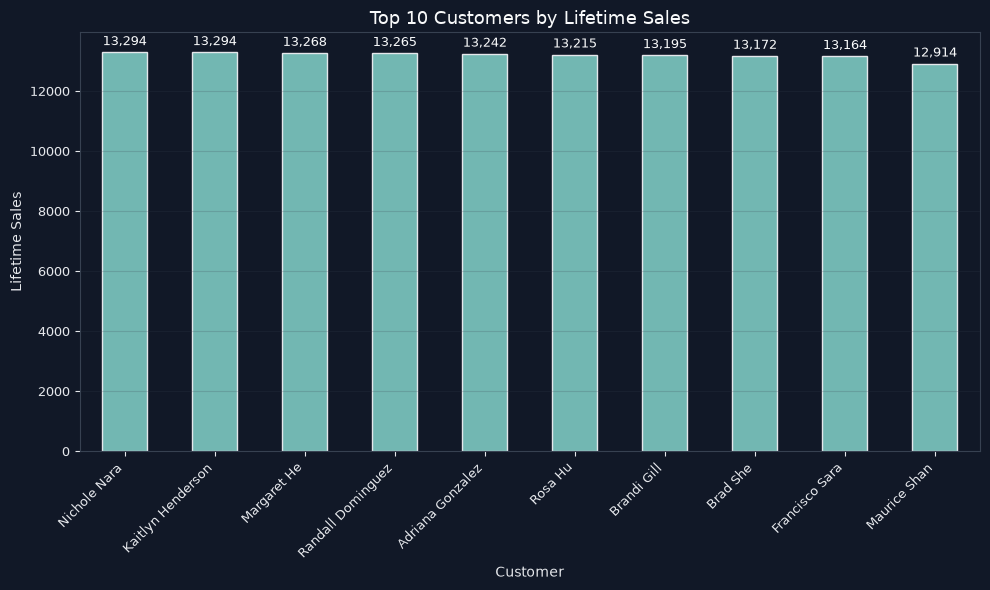

In [4]:
# Create a clean working dataframe for plotting
plot_df = df.copy()

for col in [
    "TOTAL_ORDERS",
    "TOTAL_ORDER_LINES",
    "TOTAL_UNITS_PURCHASED",
    "LIFETIME_SALES",
    "AVG_LINE_VALUE",
    "DAYS_SINCE_LAST_ORDER",
]:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

plot_df = plot_df.dropna(subset=["LIFETIME_SALES", "TOTAL_ORDERS"]).copy()
plot_df["COUNTRY"] = (
    plot_df["COUNTRY"]
    .astype("string")
    .str.strip()
    .replace(["N/A", "n/a", "NA", "na", "NaN", "NULL", "null", "None", "none", ""], pd.NA)
)
plot_df["GENDER"] = (
    plot_df["GENDER"]
    .astype("string")
    .str.strip()
    .replace(["N/A", "n/a", "NA", "na", "NaN", "NULL", "null", "None", "none", ""], pd.NA)
)

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "#111827",
    "axes.facecolor": "#111827",
    "axes.edgecolor": "#374151",
    "axes.labelcolor": "#E5E7EB",
    "axes.titlecolor": "#F9FAFB",
    "xtick.color": "#E5E7EB",
    "ytick.color": "#E5E7EB",
    "text.color": "#E5E7EB",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "font.family": "sans-serif",
    "grid.color": "#374151",
})


def add_bar_labels(ax, prefix="", suffix=""):
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f"{prefix}{val:,.0f}{suffix}" for val in container.datavalues],
            padding=3,
            fontsize=9,
            color="#F9FAFB",
        )

# Prepare summary data for dashboard charts
country_sales = (
    plot_df.dropna(subset=["COUNTRY"])
    .groupby("COUNTRY", dropna=True)["LIFETIME_SALES"]
    .sum()
    .sort_values(ascending=False)
)

plot_df["CUSTOMER_NAME"] = (
    plot_df["FIRST_NAME"].fillna("").astype(str).str.strip()
    + " " +
    plot_df["LAST_NAME"].fillna("").astype(str).str.strip()
).str.replace(r"\s+", " ", regex=True).str.strip()
plot_df = plot_df[plot_df["CUSTOMER_NAME"] != ""].copy()

customer_lifetime_sales = (
    plot_df.sort_values("LIFETIME_SALES", ascending=False)
    .head(10)
    .set_index("CUSTOMER_NAME")["LIFETIME_SALES"]
)

gender_sales = (
    plot_df.dropna(subset=["GENDER"])
    .groupby("GENDER", dropna=True)["LIFETIME_SALES"]
    .sum()
    .sort_values(ascending=False)
)

# Compact 2x2 dashboard layout
fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor="#111827")
fig.suptitle("Customer Performance Dashboard", fontsize=18, y=1.02)

for ax in axes.flat:
    ax.set_facecolor("#111827")

# 1. Lifetime sales distribution
axes[0, 0].hist(plot_df["LIFETIME_SALES"], bins=20, color="#4C78A8", edgecolor="#E5E7EB")
axes[0, 0].set_title("Lifetime Sales Distribution")
axes[0, 0].set_xlabel("Lifetime Sales")
axes[0, 0].set_ylabel("Customers")
axes[0, 0].grid(True, alpha=0.2)

# 2. Orders vs revenue
axes[0, 1].scatter(plot_df["TOTAL_ORDERS"], plot_df["LIFETIME_SALES"], alpha=0.7, color="#54A24B")
axes[0, 1].set_title("Total Orders vs Lifetime Sales")
axes[0, 1].set_xlabel("Total Orders")
axes[0, 1].set_ylabel("Lifetime Sales")
axes[0, 1].grid(True, alpha=0.25)

# 3. Top countries by revenue
country_sales.head(10).plot(kind="bar", ax=axes[1, 0], color="#F58518", edgecolor="#E5E7EB")
axes[1, 0].set_title("Top Countries by Lifetime Sales")
axes[1, 0].set_xlabel("Country")
axes[1, 0].set_ylabel("Total Sales")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].grid(True, axis="y", alpha=0.2)
add_bar_labels(axes[1, 0], suffix="")

# 4. Revenue by gender
gender_sales.plot(kind="bar", ax=axes[1, 1], color="#E45756", edgecolor="#E5E7EB")
axes[1, 1].set_title("Lifetime Sales by Gender")
axes[1, 1].set_xlabel("Gender")
axes[1, 1].set_ylabel("Total Sales")
axes[1, 1].tick_params(axis="x", rotation=0)
axes[1, 1].grid(True, axis="y", alpha=0.2)
add_bar_labels(axes[1, 1], suffix="")

plt.tight_layout()
plt.show()

# Optional detail chart for top customers
plt.figure(figsize=(10, 6), facecolor="#111827")
customer_lifetime_sales.plot(kind="bar", color="#72B7B2", edgecolor="#E5E7EB")
plt.title("Top 10 Customers by Lifetime Sales")
plt.xlabel("Customer")
plt.ylabel("Lifetime Sales")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.2)
add_bar_labels(plt.gca(), suffix="")
plt.tight_layout()
plt.show()